In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
file = "C:/Users/v-phyuthant/PYTHON/PROJECTs/Zomato_data.csv"
df=pd.read_csv(file)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


# Checking_and changing data type from string to float

In [5]:
df.dtypes

name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object

In [6]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0];
    return float(value)

df['rate']=df['rate'].apply(handleRate)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


# Visualization of Restaurant Type Counts from the 'Listed_in(Type)' Column

Text(0, 0.5, 'Counts')

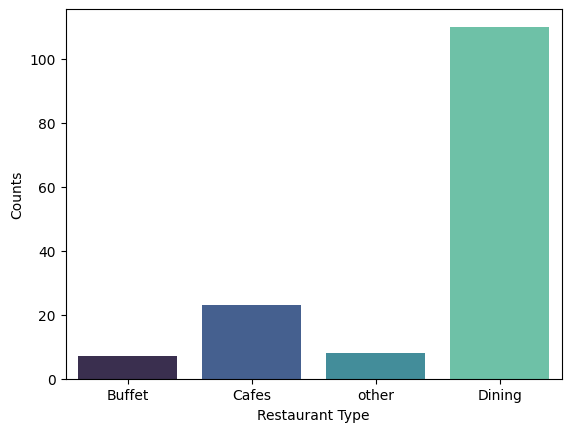

In [8]:
sns.countplot(x=df['listed_in(type)'],hue = df['listed_in(type)'],palette = 'mako')
plt.xlabel ("Restaurant Type")
plt.ylabel ("Counts")

# Visualization of Votes for each restaurant type

In [9]:
Votes_for_groups = df.groupby('listed_in(type)')['votes'].sum()
print (Votes_for_groups)

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64


Text(0.5, 1.0, 'Votes for each restaurant type')

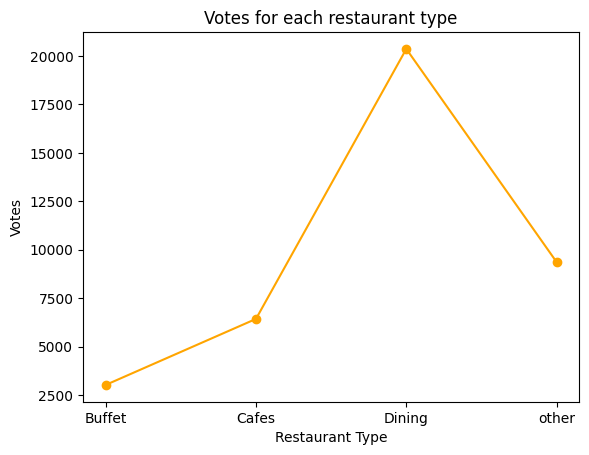

In [10]:
Votes = pd.DataFrame({'Votes':Votes_for_groups})
plt.plot(Votes, c= 'orange',marker ='o')
plt.xlabel("Restaurant Type")
plt.ylabel("Votes")
plt.title("Votes for each restaurant type")

Conclusion: Dining restaurants are preferred by a larger number of individuals.

In [11]:
max_votes = df['votes'].max()
restaurant_with_max_votes = df.loc[df['votes']==max_votes,'name']
print(f"maximum_votes:{max_votes},restaurant_with_max_votes:{restaurant_with_max_votes.values}")

maximum_votes:4884,restaurant_with_max_votes:['Empire Restaurant']


In [12]:
restaurant_with_maximum_votes = df.nlargest(10,'votes')[['name','votes']]
print(restaurant_with_maximum_votes)

                  name  votes
38   Empire Restaurant   4884
86       Meghana Foods   4401
7               Onesta   2556
44              Onesta   2556
65         Kabab Magic   1720
37     Szechuan Dragon   1647
54        Roving Feast   1047
2      San Churro Cafe    918
14     San Churro Cafe    918
67  Gustoes Beer House    868


# Identifying the Restaurant Name with the Maximum Votes

In [13]:
max_votes = df['votes'].max()
restaurant_with_max_votes = df.loc[df['votes']==max_votes,'name']
print(f"max_votes:{max_votes},restaurant_with_max_votes:{restaurant_with_max_votes.values}")

max_votes:4884,restaurant_with_max_votes:['Empire Restaurant']


NOTE: Using df.max() and df.loc[] function 

In [14]:
Restaurant_with_maximum_votes = df.nlargest(10,'votes')[['name','votes']]
print (Restaurant_with_maximum_votes)

                  name  votes
38   Empire Restaurant   4884
86       Meghana Foods   4401
7               Onesta   2556
44              Onesta   2556
65         Kabab Magic   1720
37     Szechuan Dragon   1647
54        Roving Feast   1047
2      San Churro Cafe    918
14     San Churro Cafe    918
67  Gustoes Beer House    868


NOTE: Using df.nlargest()

# Identifying about Online Orders

<Axes: xlabel='online_order', ylabel='count'>

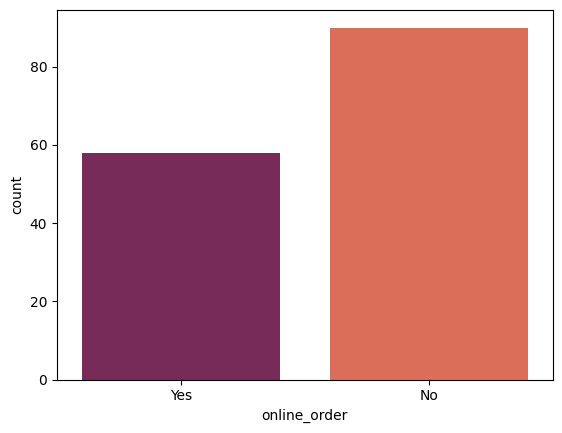

In [15]:
sns.countplot(x=df['online_order'],hue = df['online_order'],palette = 'rocket')

Conclusion: This suggests that a majority of the restaurants do not accept online orders.

# Identifying about Rate range

Text(0.5, 1.0, 'Rate Range')

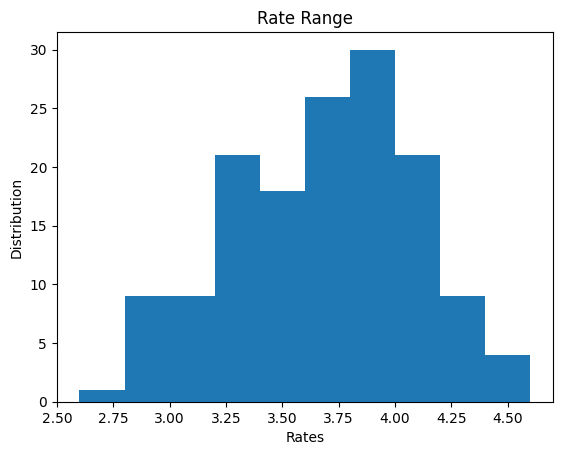

In [16]:
plt.hist(df['rate'])
plt.xlabel ("Rates")
plt.ylabel ("Distribution")
plt.title ("Rate Range")

Conclusion: The majority of restaurants received ratings ranging from 3.8 to 4.1 .

# Identifying about approx cost for two people

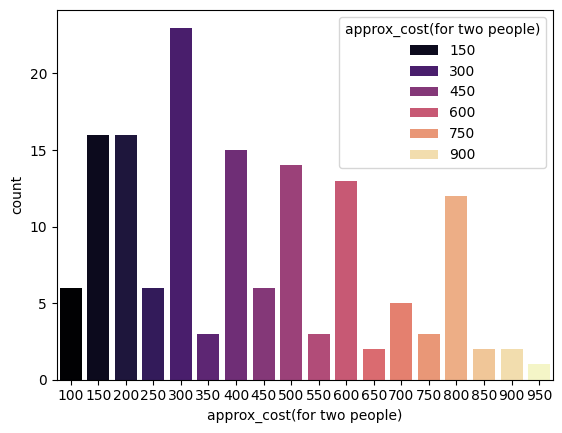

In [65]:
sns.countplot(x=df['approx_cost(for two people)'],hue =df['approx_cost(for two people)'],palette ='magma')
plt.show()

Conclusion: The majority of couples prefer restaurants with an approximate cost of 300 rupees.

# Identifying about restaurant types based on online & offline orders 

In [23]:
pivot_tbl = df.pivot_table(index ='listed_in(type)',columns= 'online_order',aggfunc ='size',fill_value=0)
pivot_tbl['row_total'] = pivot_tbl.sum(axis=1) 
pivot_tbl = pivot_tbl.sort_values('row_total',ascending =False)
pivot_tbl = pivot_tbl.drop (columns ='row_total')
print(pivot_tbl)

online_order     No  Yes
listed_in(type)         
Dining           77   33
Cafes             8   15
other             2    6
Buffet            3    4


Text(0.5, 1.0, 'Heatmap')

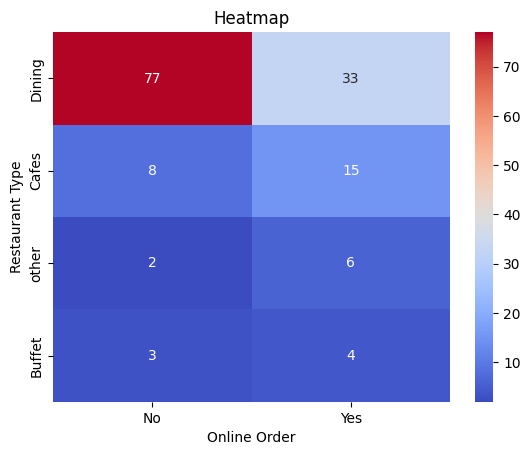

In [24]:
sns.heatmap(pivot_tbl,annot =True,cmap ='coolwarm',fmt ='d')
plt.xlabel('Online Order')
plt.ylabel ('Restaurant Type')
plt.title('Heatmap')

CONCLUSION: Dining restaurants primarily accept offline orders, whereas cafes primarily receive online orders. This suggests that clients prefer to place orders in person at restaurants, but prefer online ordering at cafes.